In [1]:
import numpy as np

def compute_angle(a, b, c):
    """
    Angle at point b (in degrees)
    a, b, c are (x, y, z)
    """
    ba = a - b
    bc = c - b

    cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))

    return np.degrees(angle)

In [18]:
import pandas as pd

# Landmark indices
LS, RS = 11, 12
LE, RE = 13, 14
LW, RW = 15, 16
LH, RH = 23, 24
LK, RK = 25, 26
LA, RA = 27, 28


def extract_features(df: pd.DataFrame):
    features = []

    grouped = df.groupby("frame")

    for frame_id, group in grouped:
        group = group.sort_values("landmark")

        coords = group[["x", "y", "z"]].values

        # Right side only (simpler, consistent)
        shoulder = coords[RS]
        elbow = coords[RE]
        wrist = coords[RW]
        hip = coords[RH]
        knee = coords[RK]
        ankle = coords[RA]

        # 1. Elbow angle
        elbow_angle = compute_angle(shoulder, elbow, wrist)

        # 2. Shoulder angle
        shoulder_angle = compute_angle(elbow, shoulder, hip)

        # 3. Hip angle
        hip_angle = compute_angle(shoulder, hip, knee)

        # 4. Body alignment (shoulder-hip-ankle)
        alignment = compute_angle(shoulder, hip, ankle)

        # 5. Depth (use shoulder height)
        depth = -(shoulder[1] - wrist[1])  # y after normalization

        features.append({
            "frame": frame_id,
            "elbow_angle": elbow_angle,
            "shoulder_angle": shoulder_angle,
            "hip_angle": hip_angle,
            "alignment": alignment,
            "depth": depth
        })

    return pd.DataFrame(features)

In [19]:
df = pd.read_csv("../outputs/keypoints/push_up_smoothed.csv")

features_df = extract_features(df)
print(features_df.head())

   frame  elbow_angle  shoulder_angle   hip_angle   alignment     depth
0      0   163.262826       65.846144  151.109508  159.109090 -0.940487
1      1   162.978467       65.469106  151.447442  159.325183 -0.943279
2      2   162.886179       65.099136  151.814151  159.643558 -0.945618
3      3   162.697116       64.443032  152.497694  160.264076 -0.949667
4      4   162.520168       63.819337  153.154956  160.775509 -0.953709


<Axes: >

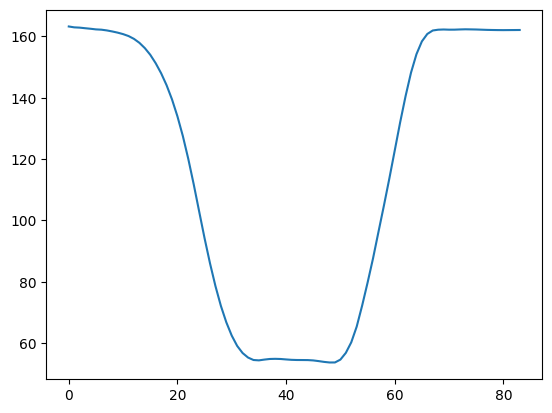

In [20]:
features_df["elbow_angle"].plot()

<Axes: >

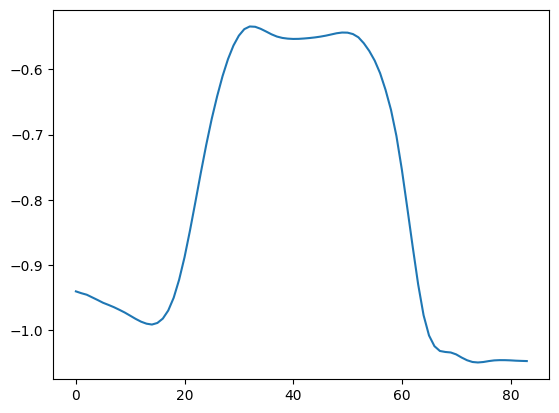

In [21]:
features_df["depth"].plot()

In [37]:
# rep detection
from scipy.signal import find_peaks


def detect_reps(depth_signal):
    """
    Returns indices of rep bottoms (deepest points)
    """

    # Find peaks (bottom of push-up)
    peaks, _ = find_peaks(
        depth_signal,
        distance=10,      # minimum frames between reps
        prominence=0.05  # filters noise
    )

    return peaks

In [38]:
peaks = detect_reps(features_df["depth"].values)

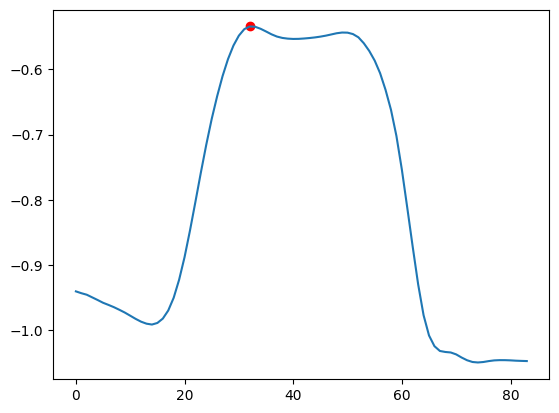

In [39]:
import matplotlib.pyplot as plt
plt.plot(features_df["depth"])
plt.scatter(peaks, features_df["depth"].iloc[peaks], color='red')
plt.show()

In [1]:
def aggregate_features(features_df):
    return {
        "min_elbow_angle": features_df["elbow_angle"].min(),
        "max_elbow_angle": features_df["elbow_angle"].max(),

        "max_depth": features_df["depth"].max(),
        "min_depth": features_df["depth"].min(),

        "avg_alignment": features_df["alignment"].mean(),
        "min_alignment": features_df["alignment"].min(),

        "min_hip_angle": features_df["hip_angle"].min(),
        "avg_hip_angle": features_df["hip_angle"].mean(),

        # Optional: dynamics
        "elbow_range": features_df["elbow_angle"].max() - features_df["elbow_angle"].min(),
        "depth_range": features_df["depth"].max() - features_df["depth"].min(),
    }